# Topic 14 — MLE vs Bayesian (PyMC) vs GPR
## Ti–6Al–4V L-PBF Fatigue Data (FatigueData-AM2022)

**All plots use log₁₀(σₐ) on the x-axis and log₁₀(Nf) on the y-axis**
— matching the professor's notebook exactly.

Install: `pip install numpy pandas matplotlib openpyxl pymc arviz scikit-learn`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

xlsx_path = Path("FatigueData-AM2022.xlsx")   # adjust path if needed

sn    = pd.read_excel(xlsx_path, sheet_name="S-N")
param = pd.read_excel(xlsx_path, sheet_name="parameter", header=1)

def clean_cols(df):
    df = df.copy()
    df.columns = (df.columns.astype(str).str.strip().str.lower()
        .str.replace("\n", " ", regex=False)
        .str.replace(r"\s+", "_", regex=True)
        .str.replace(r"[^\w_]+", "", regex=True))
    return df

sn    = clean_cols(sn)
param = clean_cols(param)

sn = sn.rename(columns={
    "life_n_cycle":            "life_N",
    "stress_amplitude_σa_mpa": "stress_amplitude_MPa",
})
param = param.rename(columns={
    "name_of_the_material":   "material",
    "types_of_am":            "am_type",
    "types_of_fatigue_tests": "fatigue_type",
    "frequency_hz":           "frequency",
})

keep = [c for c in ["dataset_id","material","am_type","fatigue_type","load_ratio","frequency"]
        if c in param.columns]
merged = sn.merge(param[keep], on="dataset_id", how="left")
merged["material_str"] = merged["material"].astype(str).str.lower()

subset = merged[merged["material_str"].str.contains(
    "ti-6al-4v|ti64|ti 6al 4v", regex=True, na=False)].copy()
subset = subset[subset["am_type"].astype(str).str.strip() == "L-PBF"].copy()
subset = subset[subset["fatigue_type"].astype(str).str.lower()
                .str.contains("uniaxial|bending", regex=True, na=False)].copy()

subset["life_N"]               = pd.to_numeric(subset["life_N"],               errors="coerce")
subset["stress_amplitude_MPa"] = pd.to_numeric(subset["stress_amplitude_MPa"], errors="coerce")
subset = subset.dropna(subset=["dataset_id","life_N","stress_amplitude_MPa"])
subset = subset[(subset["life_N"] > 0) & (subset["stress_amplitude_MPa"] > 0)].copy()

subset["log10_life_N"] = np.log10(subset["life_N"])
subset["log10_stress"] = np.log10(subset["stress_amplitude_MPa"])

print(f"Subset: {len(subset)} data points from {subset['dataset_id'].nunique()} datasets")
display(subset[["stress_amplitude_MPa","life_N","log10_stress","log10_life_N"]].describe())


Subset: 3726 data points from 382 datasets


,stress_amplitude_MPa,life_N,log10_stress,log10_life_N
count,3726.000000,3.726000e+03,3726.000000,3726.000000
mean,310.103774,2.932115e+07,2.417949,5.574442
std,174.992937,1.758936e+08,0.265703,1.185170
min,5.760575,1.539770e+02,0.760466,2.187456
25%,174.958224,5.566229e+04,2.242934,4.745561
50%,270.430772,2.082517e+05,2.432056,5.318589
75%,400.147738,2.001286e+06,2.602220,6.301309
max,1093.410895,2.999021e+09,3.038783,9.476979


## Step 1: MLE — Basquin OLS fit (straight red line in log-log space)

MLE (Basquin log-log OLS)
  c0  = 8.2061  |  c1  = -1.0884
  B   = -0.9188  |  log10(A) = 7.5397
  σ̂  = 1.1495 log-cycles


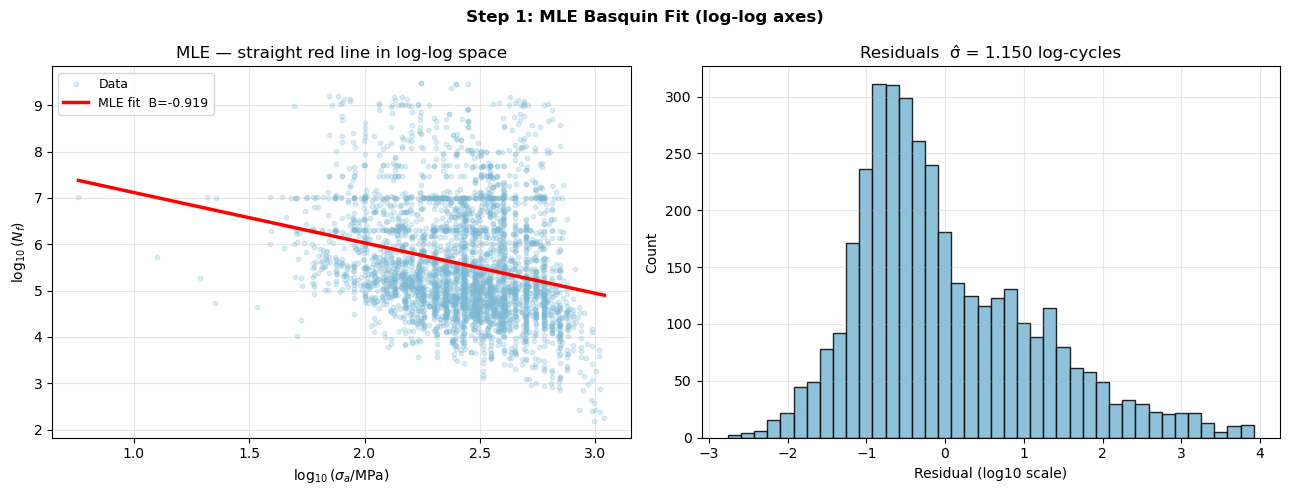

In [2]:
# ── MLE: Basquin fit in log-log space (OLS) ──────────────────────────────────
# X axis = log10(stress_amplitude),  Y axis = log10(Nf)
# This is exactly what the professor plots — straight line in log-log space

X_mle = np.column_stack([np.ones(len(subset)), subset["log10_stress"].values])
y     = subset["log10_life_N"].values

beta_mle, *_ = np.linalg.lstsq(X_mle, y, rcond=None)
c0_mle, c1_mle = beta_mle
resid_mle  = y - X_mle @ beta_mle
sigma_mle  = np.std(resid_mle, ddof=2)
B_basquin  = 1.0 / c1_mle
log10A     = -c0_mle / c1_mle

print("=" * 50)
print("MLE (Basquin log-log OLS)")
print(f"  c0  = {c0_mle:.4f}  |  c1  = {c1_mle:.4f}")
print(f"  B   = {B_basquin:.4f}  |  log10(A) = {log10A:.4f}")
print(f"  σ̂  = {sigma_mle:.4f} log-cycles")
print("=" * 50)

# ── Plot: log10(stress) on x-axis → straight line ────────────────────────────
log10_stress_grid = np.linspace(subset["log10_stress"].min(),
                                 subset["log10_stress"].max(), 300)
mle_line = c0_mle + c1_mle * log10_stress_grid   # straight line in log-log

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(subset["log10_stress"], subset["log10_life_N"],
           alpha=0.25, s=10, color="#7ab8d4", label="Data")
ax.plot(log10_stress_grid, mle_line, color="red", lw=2.5,
        label=f"MLE fit  B={B_basquin:.3f}")
ax.set_xlabel(r"$\log_{{10}}(\sigma_a / \mathrm{{MPa}})$")
ax.set_ylabel(r"$\log_{{10}}(N_f)$")
ax.set_title("MLE — straight red line in log-log space")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(resid_mle, bins=40, edgecolor="black", color="#7ab8d4", alpha=0.85)
ax.set_xlabel("Residual (log10 scale)"); ax.set_ylabel("Count")
ax.set_title(f"Residuals  σ̂ = {sigma_mle:.3f} log-cycles")
ax.grid(alpha=0.3)

plt.suptitle("Step 1: MLE Basquin Fit (log-log axes)", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


## Step 2: Bayesian Linear Regression — PyMC

Same Basquin model as MLE, but parameters `(c0, c1, sigma)` are **inferred as full distributions** via MCMC.

**Priors:**
- $c_0 \sim \mathcal{N}(8,\, 3^2)$ — intercept
- $c_1 \sim \mathcal{N}(-1,\, 1^2)$ — slope (Basquin exponent proxy)
- $\sigma \sim \text{HalfNormal}(2)$ — noise std (inferred, not fixed)


In [3]:
import pymc as pm
import arviz as az

# x is already log10(stress) — centre it for numerical stability
x_raw  = subset["log10_stress"].values
y_data = subset["log10_life_N"].values
x_mean = x_raw.mean()
xc     = x_raw - x_mean

with pm.Model() as basquin_model:
    # ── Priors ────────────────────────────────────────────────────────────────
    c0    = pm.Normal("c0",    mu=8.0,  sigma=3.0)
    c1    = pm.Normal("c1",    mu=-1.0, sigma=1.0)
    sigma = pm.HalfNormal("sigma", sigma=2.0)

    # ── Likelihood ────────────────────────────────────────────────────────────
    mu  = c0 + c1 * xc
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=y_data)

    # ── Sample ────────────────────────────────────────────────────────────────
    trace = pm.sample(
        draws=1000, tune=1000,
        chains=4, cores=1,
        progressbar=True,
        random_seed=42,
        return_inferencedata=True,
    )

print(az.summary(trace, var_names=["c0", "c1", "sigma"]))


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [c0, c1, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
c0     5.575  0.019   5.540    5.611      0.000    0.000    4826.0    2796.0   
c1    -1.088  0.070  -1.224   -0.963      0.001    0.001    6005.0    3050.0   
sigma  1.150  0.013   1.125    1.174      0.000    0.000    6553.0    2997.0   

       r_hat  
c0       1.0  
c1       1.0  
sigma    1.0  


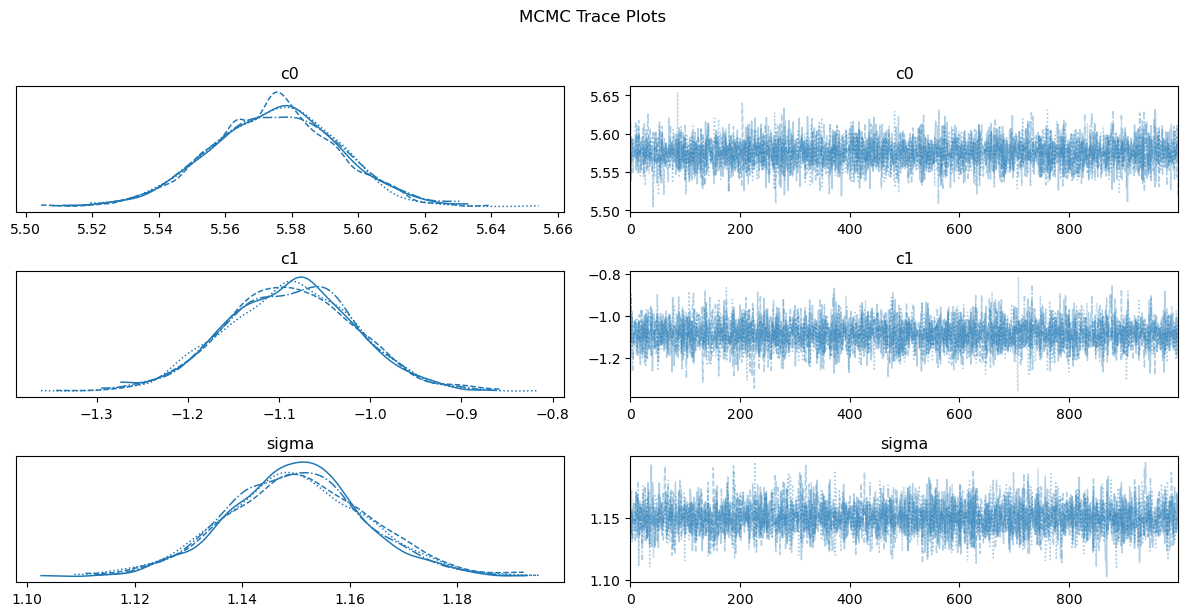

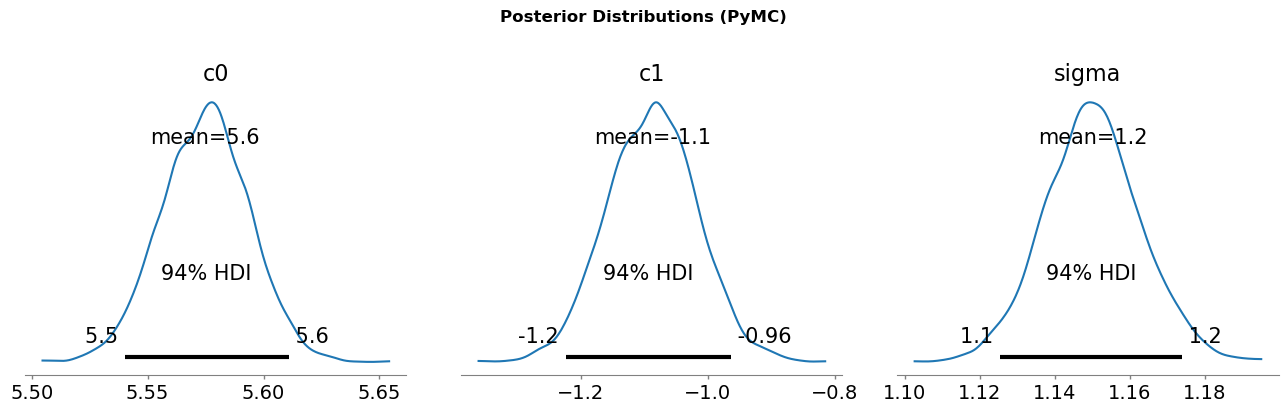

In [4]:
# ── Convergence diagnostics ──────────────────────────────────────────────────
# R-hat < 1.01 = converged.  Fuzzy caterpillar trace = good mixing.
az.plot_trace(trace, var_names=["c0", "c1", "sigma"])
plt.suptitle("MCMC Trace Plots", y=1.02)
plt.tight_layout(); plt.show()

az.plot_posterior(trace, var_names=["c0", "c1", "sigma"], figsize=(13, 4))
plt.suptitle("Posterior Distributions (PyMC)", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


In [5]:
# ── Posterior predictive lines (log10 stress on x-axis) ──────────────────────
post    = trace.posterior
c0_s    = post["c0"].values.flatten()
c1_s    = post["c1"].values.flatten()

# Shift intercept back from centred to original log10_stress scale
c0_orig = c0_s - c1_s * x_mean

# Grid is in log10(stress) — same x-axis as MLE plot
log10_stress_grid = np.linspace(subset["log10_stress"].min(),
                                 subset["log10_stress"].max(), 300)

rng   = np.random.default_rng(0)
idx   = rng.choice(len(c0_orig), size=300, replace=False)
lines = np.array([c0_orig[i] + c1_s[i] * log10_stress_grid for i in idx])
bayes_mean = lines.mean(axis=0)
bayes_std  = lines.std(axis=0)


## Step 3: Gaussian Process Regression (GPR)

GPR does **not** assume a straight line. It fits any smooth curve and gives uncertainty bands that widen where data are sparse.

- Input: $\log_{10}(\sigma_a)$ — same x-axis as MLE and Bayesian
- Output: $\log_{10}(N_f)$ with posterior mean + uncertainty
- Kernel: RBF (smoothness) + WhiteKernel (noise)


In [6]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C

# Subsample 400 points for speed (GPR is O(n^3))
rng_gpr = np.random.default_rng(42)
idx_gpr = rng_gpr.choice(len(subset), size=400, replace=False)

# X = log10(stress),  y = log10(Nf)  — same axes as MLE and Bayesian
X_gpr = subset["log10_stress"].values[idx_gpr].reshape(-1, 1)
y_gpr = subset["log10_life_N"].values[idx_gpr]

# Normalise for GPR stability
X_mu, X_sd = X_gpr.mean(), X_gpr.std()
y_mu, y_sd = y_gpr.mean(), y_gpr.std()
Xn = (X_gpr - X_mu) / X_sd
yn = (y_gpr - y_mu) / y_sd

kernel = (C(1.0, (1e-3, 1e3))
          * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 10))
          + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-4, 1.0)))

gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5,
                                random_state=0, normalize_y=False)
gpr.fit(Xn, yn)
print("Optimised kernel:", gpr.kernel_)

# Predict on the same log10_stress_grid used for MLE and Bayesian
Xn_grid     = (log10_stress_grid.reshape(-1, 1) - X_mu) / X_sd
mu_n, std_n = gpr.predict(Xn_grid, return_std=True)
mu_gpr      = mu_n  * y_sd + y_mu     # back to log10(Nf) scale
std_gpr     = std_n * y_sd


Optimised kernel: 0.334**2 * RBF(length_scale=0.106) + WhiteKernel(noise_level=0.905)


## Step 4: Comparison Plots

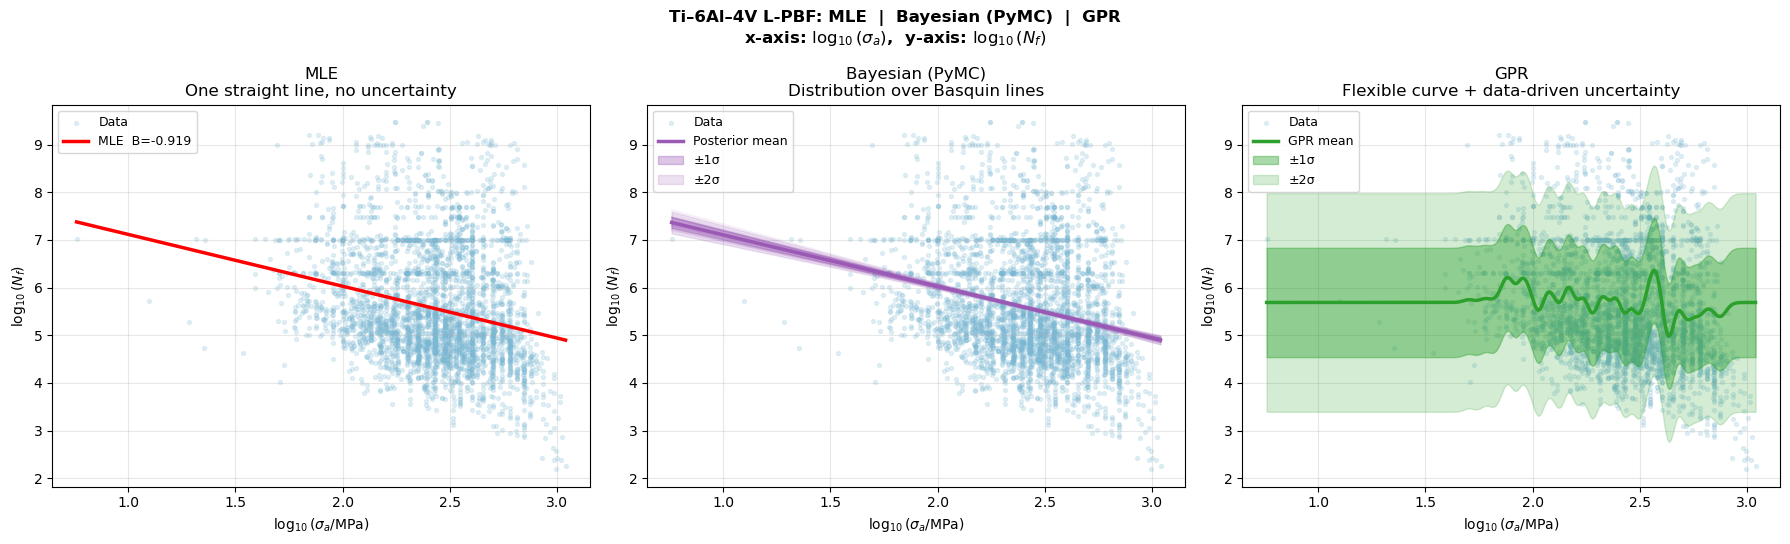

In [7]:
# ── Three-way comparison — all on log10(stress) x-axis ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle(
    r"Ti–6Al–4V L-PBF: MLE  |  Bayesian (PyMC)  |  GPR"
    "\n" r"x-axis: $\log_{{10}}(\sigma_a)$,  y-axis: $\log_{{10}}(N_f)$",
    fontsize=12, fontweight="bold"
)

# ── Panel 1: MLE ─────────────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(subset["log10_stress"], subset["log10_life_N"],
           alpha=0.2, s=8, color="#7ab8d4", label="Data")
ax.plot(log10_stress_grid, mle_line, color="red", lw=2.5,
        label=f"MLE  B={B_basquin:.3f}")
ax.set_xlabel(r"$\log_{{10}}(\sigma_a / \mathrm{{MPa}})$")
ax.set_ylabel(r"$\log_{{10}}(N_f)$")
ax.set_title("MLE\nOne straight line, no uncertainty")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 2: Bayesian PyMC ───────────────────────────────────────────────────
ax = axes[1]
ax.scatter(subset["log10_stress"], subset["log10_life_N"],
           alpha=0.2, s=8, color="#7ab8d4", label="Data", zorder=1)
for line in lines[::5]:
    ax.plot(log10_stress_grid, line, color="#9b59b6", alpha=0.06, lw=1, zorder=2)
ax.plot(log10_stress_grid, bayes_mean, color="#9b59b6", lw=2.5,
        label="Posterior mean", zorder=3)
ax.fill_between(log10_stress_grid,
                bayes_mean - bayes_std, bayes_mean + bayes_std,
                alpha=0.35, color="#9b59b6", label="±1σ", zorder=3)
ax.fill_between(log10_stress_grid,
                bayes_mean - 2*bayes_std, bayes_mean + 2*bayes_std,
                alpha=0.18, color="#9b59b6", label="±2σ", zorder=3)
ax.set_xlabel(r"$\log_{{10}}(\sigma_a / \mathrm{{MPa}})$")
ax.set_ylabel(r"$\log_{{10}}(N_f)$")
ax.set_title("Bayesian (PyMC)\nDistribution over Basquin lines")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 3: GPR ─────────────────────────────────────────────────────────────
ax = axes[2]
ax.scatter(subset["log10_stress"], subset["log10_life_N"],
           alpha=0.2, s=8, color="#7ab8d4", label="Data", zorder=1)
ax.plot(log10_stress_grid, mu_gpr, color="#2ca02c", lw=2.5,
        label="GPR mean", zorder=3)
ax.fill_between(log10_stress_grid,
                mu_gpr - std_gpr, mu_gpr + std_gpr,
                alpha=0.40, color="#2ca02c", label="±1σ", zorder=3)
ax.fill_between(log10_stress_grid,
                mu_gpr - 2*std_gpr, mu_gpr + 2*std_gpr,
                alpha=0.20, color="#2ca02c", label="±2σ", zorder=3)
ax.set_xlabel(r"$\log_{{10}}(\sigma_a / \mathrm{{MPa}})$")
ax.set_ylabel(r"$\log_{{10}}(N_f)$")
ax.set_title("GPR\nFlexible curve + data-driven uncertainty")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


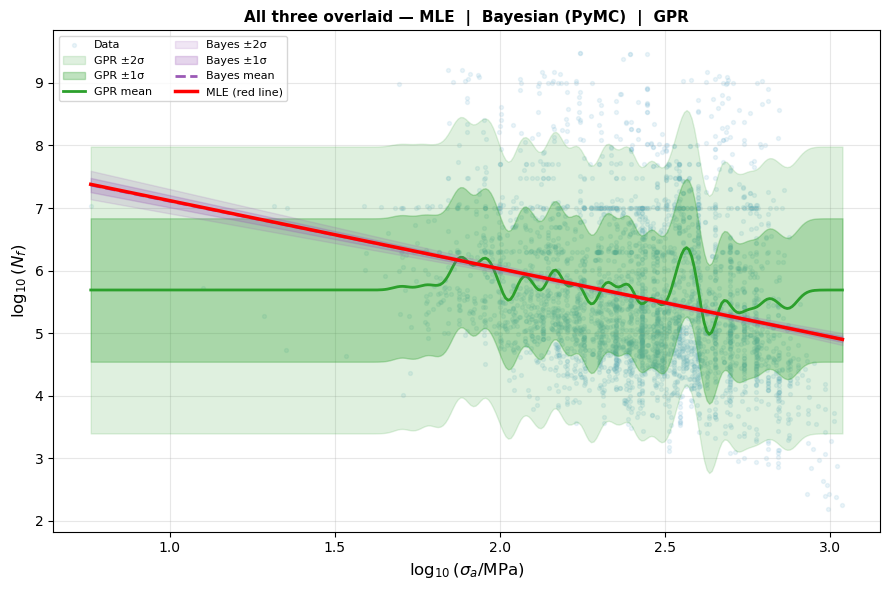

In [8]:
# ── Overlay all three on one axes ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(subset["log10_stress"], subset["log10_life_N"],
           alpha=0.15, s=8, color="#7ab8d4", label="Data", zorder=1)

# GPR bands
ax.fill_between(log10_stress_grid,
                mu_gpr - 2*std_gpr, mu_gpr + 2*std_gpr,
                alpha=0.15, color="#2ca02c", label="GPR ±2σ", zorder=2)
ax.fill_between(log10_stress_grid,
                mu_gpr - std_gpr,   mu_gpr + std_gpr,
                alpha=0.30, color="#2ca02c", label="GPR ±1σ", zorder=3)
ax.plot(log10_stress_grid, mu_gpr, color="#2ca02c", lw=2,
        label="GPR mean", zorder=4)

# Bayesian bands
ax.fill_between(log10_stress_grid,
                bayes_mean - 2*bayes_std, bayes_mean + 2*bayes_std,
                alpha=0.15, color="#9b59b6", label="Bayes ±2σ", zorder=5)
ax.fill_between(log10_stress_grid,
                bayes_mean - bayes_std,   bayes_mean + bayes_std,
                alpha=0.25, color="#9b59b6", label="Bayes ±1σ", zorder=6)
ax.plot(log10_stress_grid, bayes_mean, color="#9b59b6", lw=2, ls="--",
        label="Bayes mean", zorder=7)

# MLE on top
ax.plot(log10_stress_grid, mle_line, color="red", lw=2.5,
        label="MLE (red line)", zorder=8)

ax.set_xlabel(r"$\log_{{10}}(\sigma_a / \mathrm{{MPa}})$", fontsize=12)
ax.set_ylabel(r"$\log_{{10}}(N_f)$", fontsize=12)
ax.set_title("All three overlaid — MLE  |  Bayesian (PyMC)  |  GPR",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Interpretation: MLE vs Bayesian vs GPR

All three plots now share the same axes:
- **x-axis:** $\log_{10}(\sigma_a)$ — log of stress amplitude
- **y-axis:** $\log_{10}(N_f)$ — log of fatigue life

This is the **log-log Basquin space** — a straight line here means the Basquin power law holds.

| | MLE | Bayesian (PyMC) | GPR |
|---|---|---|---|
| **Line shape** | Straight (enforced) | Straight (enforced) | Flexible curve |
| **Uncertainty** | None | On slope & intercept | On the function shape |
| **Sparse regions** | Same confidence | Slightly wider bands | Bands widen visibly |
| **Physics** | Basquin law | Basquin law | None — data driven |

**Key observations:**
1. MLE gives a single red straight line — looks precise but shows no uncertainty
2. Bayesian lines fan out around the same mean — uncertainty is small because 3700+ points constrain the slope tightly
3. GPR mean follows the data more closely and its bands widen at the edges where data is sparse — this is the most honest picture of where predictions are unreliable
4. The large residual scatter (σ̂ ≈ 1.15 log-cycles) is **real material variability** — no method eliminates it
